In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [2]:
data = pd.read_csv("./DLS_results/TE group PDMS nanoparticles.csv", index_col=2)
data = data.reset_index(drop=True)
data

,Diameter(nm),% Intensity
0,0.052484,0.0000
1,0.066558,0.0000
2,0.084406,0.0000
3,0.107040,0.0000
4,0.135744,0.0000
5,0.172145,0.0000
6,0.218308,0.0000
7,0.276849,0.0000
8,0.351088,0.0000
9,0.445236,0.0000


Text(0.5, 0, 'Diameter (nm)')

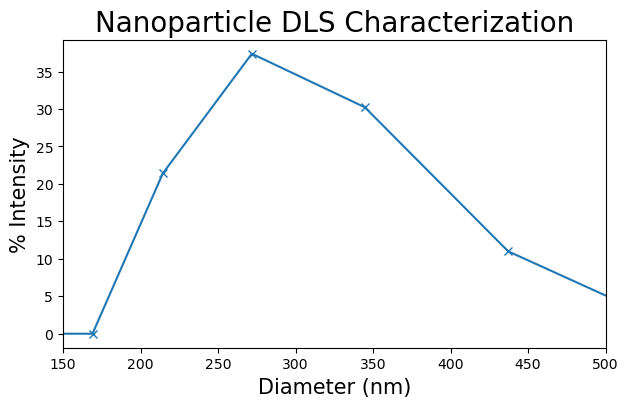

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(data['Diameter(nm)'], data['% Intensity'], marker='x')
ax.set_title('Nanoparticle DLS Characterization', fontsize=20)
ax.set_xlim(150, 500)
ax.set_ylabel('% Intensity', fontsize=15)
ax.set_xlabel('Diameter (nm)', fontsize=15)

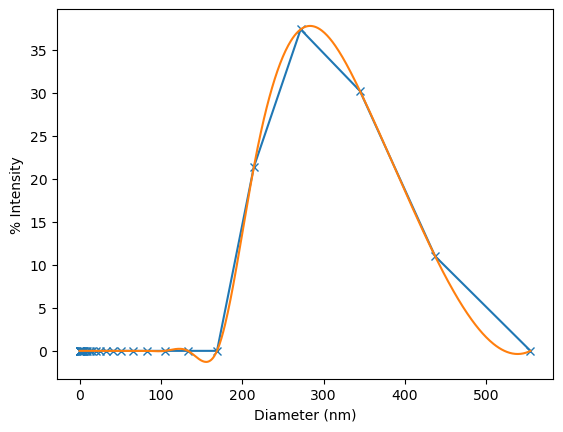

In [4]:
from scipy.interpolate import make_interp_spline
x_smooth = np.linspace(data['Diameter(nm)'].min(), data['Diameter(nm)'].max(), 500)
spl = make_interp_spline(data['Diameter(nm)'], data['% Intensity'], k=3)
y_smooth = spl(x_smooth)

fig, ax = plt.subplots()
ax.plot(data['Diameter(nm)'], data['% Intensity'],label='Data', marker='x')
ax.plot(x_smooth, y_smooth, label='Spline')
ax.set_ylabel('% Intensity')
ax.set_xlabel('Diameter (nm)')

plt.show()

In [5]:
mtt_data = pd.DataFrame(columns=['Nanoparticles', 'Gelatin', 'PDMS'])
mtt_data['Nanoparticles'] = [0.074, 0.211, 0.427, 0.054, 0.115]
mtt_data['Gelatin'] = [0.188, 0.363, 0.37, 0.058, 0.427]
mtt_data['PDMS'] = [0.504, 0.349, 0.069, np.nan, 0.086] ## index 3 is due to a bubble in the well during the reading

blank = (0.037+0.04+0.054) / 3
mtt_data = mtt_data - blank

mtt_data = (mtt_data / np.median(mtt_data['Gelatin'])) * 100
mtt_data

,Nanoparticles,Gelatin,PDMS
0,9.498956,45.198330,144.154489
1,52.400835,100.000000,95.615866
2,120.041754,102.192067,7.933194
3,3.235908,4.488518,NaN
4,22.338205,120.041754,13.256785


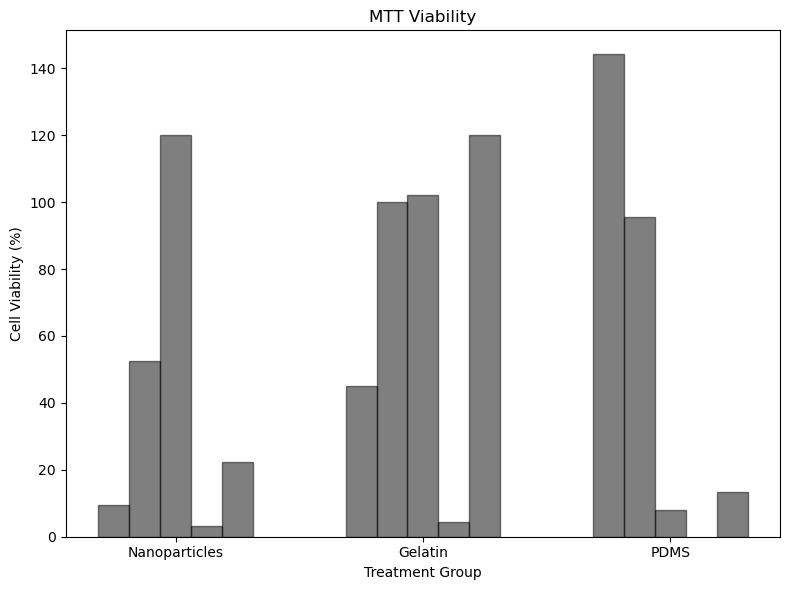

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

width = 0.5
num_reps = len(mtt_data.index)
ind = np.arange(len(mtt_data.columns)) * 4

for i, rep in enumerate(mtt_data.index):
    offset = (i - (num_reps - 1) / 2) * width
    ax.bar(ind + offset, mtt_data.loc[i], width, color='k', alpha=0.5, edgecolor='k')

ax.set_xticks(ind)
ax.set_xticklabels(mtt_data.columns)
ax.set_title('MTT Viability')
ax.set_xlabel('Treatment Group')
ax.set_ylabel('Cell Viability (%)')
plt.tight_layout()
plt.show()

In [7]:
stdev = []
for col in mtt_data.columns:
    stdev.append(mtt_data[col].std())

In [8]:
stdev

[47.809562744014315, 48.09178798288645, 66.17278997200428]

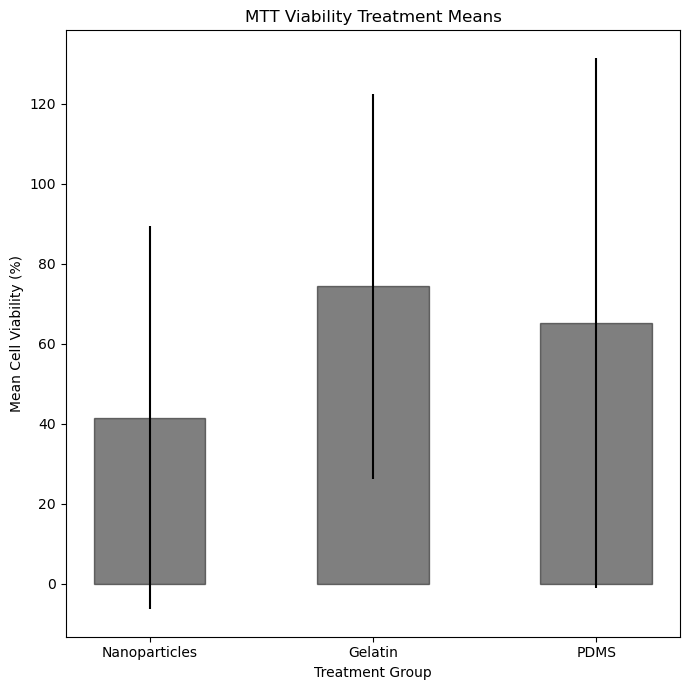

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

width = 0.5
num_reps = len(mtt_data.index)
ind = np.arange(len(mtt_data.columns))

ax.bar(ind, [mtt_data['Nanoparticles'].mean(), mtt_data['Gelatin'].mean(), (mtt_data['PDMS'].sum())/4], yerr=stdev, width=width, color='k', alpha=0.5, edgecolor='k')

ax.set_xticks(ind)
ax.set_xticklabels(mtt_data.columns)
ax.set_title('MTT Viability Treatment Means')
ax.set_xlabel('Treatment Group')
ax.set_ylabel('Mean Cell Viability (%)')
plt.tight_layout()
plt.show()

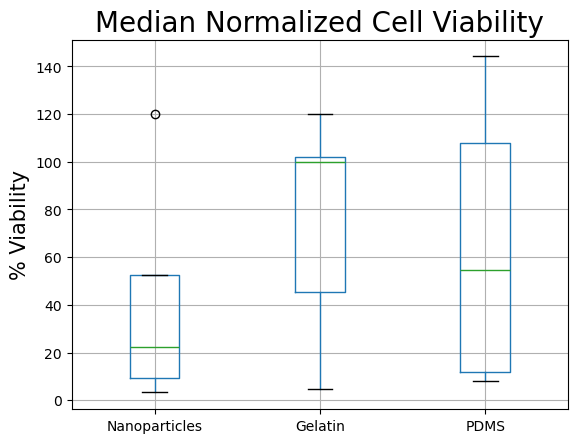

<Figure size 700x400 with 0 Axes>

In [10]:
mtt_data.boxplot()
plt.ylabel('% Viability', fontsize=15)
plt.title('Median Normalized Cell Viability', fontsize=20)
plt.figure(figsize=(7, 4))
plt.show()